**OPTIONS ANALYSIS OF GOLDMAN SACHS**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf

**PULLING THE DATA**

In [2]:
gs = yf.Ticker('GS')
expirations = gs.options
print(expirations[:10])

('2026-08-28', '2026-09-04', '2026-09-11', '2026-09-18', '2026-09-25', '2026-10-02', '2026-10-16', '2026-11-20', '2026-12-18', '2027-01-15')


**GETTING THE CALL & PUT OPTIONS**

In [3]:
opt_chain = gs.option_chain('2026-11-20')
calls = opt_chain.calls
puts = opt_chain.puts

print(calls.head())
print(calls.columns.tolist())

      contractSymbol             lastTradeDate  strike  lastPrice     bid  \
0  GS261120C00400000 2026-08-03 19:20:31+00:00   400.0     621.28  635.00   
1  GS261120C00430000 2026-08-03 19:21:32+00:00   430.0     591.75  605.15   
2  GS261120C00450000 2026-08-03 19:49:17+00:00   450.0     574.42  588.05   
3  GS261120C00460000 2026-08-03 19:23:14+00:00   460.0     561.63  578.05   
4  GS261120C00470000 2026-08-13 17:10:56+00:00   470.0     577.65  568.05   

      ask  change  percentChange  volume  openInterest  impliedVolatility  \
0  644.20     0.0            0.0     NaN             1           0.728030   
1  614.35     0.0            0.0     NaN             1           0.705569   
2  594.10     0.0            0.0     2.0             5           0.801516   
3  584.35     0.0            0.0     NaN             1           0.790163   
4  574.35     0.0            0.0     2.0             2           0.771120   

   inTheMoney contractSize currency  
0        True      REGULAR      USD 

In [4]:
current_price = gs.history(period='1d')['Close'].iloc[-1]
print(current_price)

1039.280029296875


In [5]:
calls_near_money = calls[(calls['strike'] > current_price - 100) & (calls['strike'] < current_price + 100)]
print(calls_near_money[['strike', 'lastPrice', 'bid', 'ask', 'impliedVolatility', 'inTheMoney']])

    strike  lastPrice     bid     ask  impliedVolatility  inTheMoney
72   940.0     118.55  130.00  137.05           0.394034        True
73   945.0     111.00  126.25  133.50           0.392455        True
74   950.0     112.50  123.00  129.70           0.389227        True
75   955.0     123.50  119.30  126.50           0.389159        True
76   960.0      94.95  115.35  123.20           0.388258        True
77   965.0      96.90  112.10  119.65           0.385756        True
78   970.0     104.05  109.10  116.05           0.382765        True
79   975.0     102.50  106.00  112.45           0.379569        True
80   980.0     104.55  102.50  109.25           0.378272        True
81   985.0      90.40   99.50  105.55           0.374137        True
82   990.0      85.15   96.45  102.50           0.373145        True
83   995.0      73.05   95.10   99.35           0.371390        True
84  1000.0      85.50   92.00   97.30           0.374960        True
85  1010.0      79.00   84.75   90

In [6]:
option_row = calls[calls['strike'] == 1040]
premium = option_row['lastPrice'].values[0]
strike = 1040
print(premium)

72.0


In [7]:
possible_stock_prices = np.linspace(current_price - 200, current_price + 200, 100)
print(possible_stock_prices)

[ 839.2800293   843.32043334  847.36083738  851.40124142  855.44164546
  859.4820495   863.52245354  867.56285758  871.60326162  875.64366566
  879.6840697   883.72447374  887.76487778  891.80528182  895.84568586
  899.8860899   903.92649394  907.96689798  912.00730202  916.04770606
  920.0881101   924.12851415  928.16891819  932.20932223  936.24972627
  940.29013031  944.33053435  948.37093839  952.41134243  956.45174647
  960.49215051  964.53255455  968.57295859  972.61336263  976.65376667
  980.69417071  984.73457475  988.77497879  992.81538283  996.85578687
 1000.89619091 1004.93659495 1008.97699899 1013.01740303 1017.05780707
 1021.09821112 1025.13861516 1029.1790192  1033.21942324 1037.25982728
 1041.30023132 1045.34063536 1049.3810394  1053.42144344 1057.46184748
 1061.50225152 1065.54265556 1069.5830596  1073.62346364 1077.66386768
 1081.70427172 1085.74467576 1089.7850798  1093.82548384 1097.86588788
 1101.90629192 1105.94669596 1109.9871     1114.02750404 1118.06790808
 1122.

In [8]:
intrinsic_value = np.maximum(possible_stock_prices - strike, 0)
payoff = intrinsic_value - premium

**VISUALISATION**

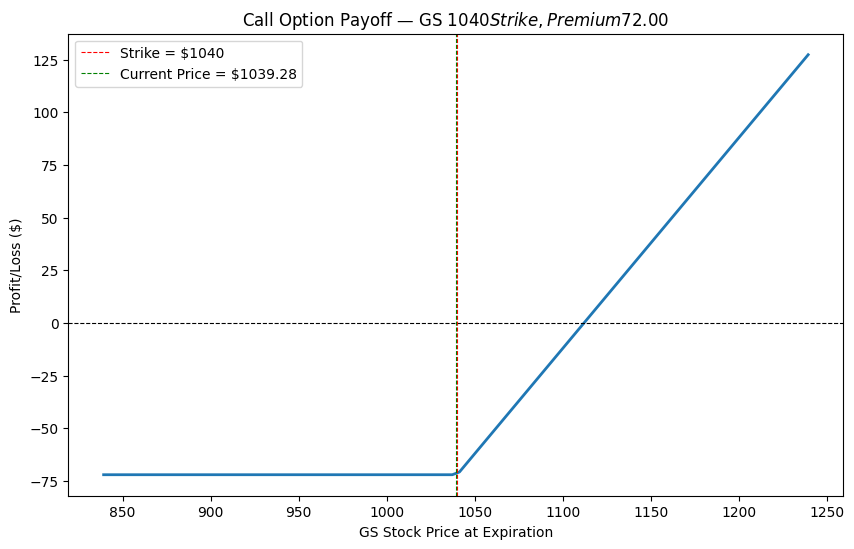

In [9]:
plt.figure(figsize=(10,6))
plt.title(f'Call Option Payoff — GS 1040 Strike, Premium {premium:.2f} Dollars')
plt.plot(possible_stock_prices, payoff, linewidth=2)
plt.axhline(y=0, color='black', linestyle='--', linewidth=0.8)
plt.axvline(x=strike, color='red', linestyle='--', linewidth=0.8, label=f'Strike = ${strike}')
plt.axvline(x=current_price, color='green', linestyle='--', linewidth=0.8, label=f'Current Price = ${current_price:.2f}')
plt.xlabel('GS Stock Price at Expiration')
plt.ylabel('Profit/Loss ($)')
plt.title(f'Call Option Payoff — GS $1040 Strike, Premium ${premium:.2f}')
plt.legend()
plt.show()

**Put-Call Parity**

In [10]:
put_row = puts[puts['strike'] == 1040]
put_premium = put_row['lastPrice'].values[0]
print(put_premium)

76.75


In [11]:
from datetime import datetime

today = datetime.now()
expiry = datetime(2026, 11, 20)
T = (expiry - today).days / 365
r = 0.05

left_side = premium + strike * np.exp(-r * T)
right_side = put_premium + current_price

print(left_side, right_side)

1099.3975273391898 1116.030029296875
